# Fase 3 — Análisis Estadístico

Valida con tests formales si existen diferencias significativas entre elementos
(Fire, Water, Earth, Wind) en los KPIs de rendimiento del jugador.

**Entradas:** `data/processed/sessions.parquet`, `rooms.parquet`  
**Salidas:** `data/exports/statistical_results.csv`, figuras `reports/figures/fig4_*.png`

> **Nota sobre muestra:** Fire=11, Water=8, Earth=5, Wind=6 sesiones (30 limpias WebGL).  
> Todos los grupos están por debajo de n=30. Los tests son **orientativos** — resultados
> estadísticamente robustos requieren n≥30 por elemento. α = 0.05.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import scikit_posthocs as sp
import pingouin as pg
import pymannkendall as mk

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from preprocessing import run_pipeline
from cleaning import filter_clean, check_sample_size
from visualization import (PALETTE_ELEM, boxplot_by_element, correlation_heatmap,
                            qq_plot, scatter_binary, temporal_line)

PROCESSED_DIR = Path('..') / 'data' / 'processed'
EXPORTS_DIR   = Path('..') / 'data' / 'exports'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ALPHA = 0.05

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


## 1. Carga de datos — TFM-18

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')
df_levels   = pd.read_parquet(PROCESSED_DIR / 'levels.parquet')
df_rooms    = pd.read_parquet(PROCESSED_DIR / 'rooms.parquet')

# cast_accuracy global por sesión
cast_acc_session = df_rooms.groupby('sessionId')['cast_accuracy'].mean().rename('cast_accuracy')
df_sessions = df_sessions.merge(cast_acc_session, on='sessionId', how='left')

# cast_accuracy desglosada por hechizo (mejora B)
for spell in ['Projectile', 'Beam', 'Blast', 'AOE']:
    miss_col = f'miss_{spell}'
    cast_col = f'cast_{spell}'
    if miss_col in df_rooms.columns and cast_col in df_rooms.columns:
        acc = df_rooms.groupby('sessionId').apply(
            lambda g: 1 - (g[miss_col].sum() / g[cast_col].sum()) if g[cast_col].sum() > 0 else np.nan
        ).rename(f'cast_accuracy_{spell}')
        df_sessions = df_sessions.merge(acc, on='sessionId', how='left')

# Status effects y bloqueos por sesión — agregar desde rooms (mejora A)
status_cols  = [c for c in df_rooms.columns if c.startswith('status_')]
blocked_cols = [c for c in df_rooms.columns if c.startswith('blocked_')]

if status_cols:
    status_sess = df_rooms.groupby('sessionId')[status_cols].sum()
    df_sessions = df_sessions.merge(status_sess, on='sessionId', how='left')

if blocked_cols:
    blocked_agg = df_rooms.groupby('sessionId')[blocked_cols].sum()
    blocked_agg['total_blocked'] = blocked_agg.sum(axis=1)
    df_sessions = df_sessions.merge(blocked_agg[['total_blocked']], on='sessionId', how='left')

print(f'Sesiones totales : {len(df_sessions)}')
print(f'Niveles totales  : {len(df_levels)}')
print(f'Salas totales    : {len(df_rooms)}')
print(f'Status cols añadidas: {status_cols}')
print(f'Bloqueos añadidos: total_blocked')

Sesiones totales : 53
Niveles totales  : 107
Salas totales    : 534
Status cols añadidas: ['status_Burn', 'status_Stun', 'status_Slow', 'status_Knockback']
Bloqueos añadidos: total_blocked


In [3]:
# Filtrar sesiones sospechosas para análisis estadístico
df_clean = filter_clean(df_sessions, verbose=True)

# Advertencia de tamaño de muestra por elemento
counts = check_sample_size(df_clean, group_col='playerElement', min_per_group=30)
print()
print(counts.to_string(index=False))

filter_clean: 35 sesiones limpias de 53 totales (18 sospechosas eliminadas)
ADVERTENCIA: grupos con menos de 30 sesiones (tests estadisticos orientativos): ['Earth', 'Fire', 'Water', 'Wind']

playerElement  n_sessions  sufficient
        Earth           7       False
         Fire          11       False
        Water           9       False
         Wind           8       False


## 2. Normalidad — Shapiro-Wilk — TFM-23

In [4]:
KPI_COLS = ['kd_ratio', 'kills_per_min', 'cast_accuracy', 'totalDeaths', 'levelsCompleted']

# Shapiro-Wilk global (todos los elementos juntos)
shapiro_rows = []
for col in KPI_COLS:
    data = df_clean[col].dropna()
    if len(data) >= 3:
        stat, p = stats.shapiro(data)
        normal = p >= ALPHA
        shapiro_rows.append({'variable': col, 'statistic': round(stat, 4),
                             'p_value': round(p, 4), 'normal': normal})
        print(f'{col:20} W={stat:.4f}  p={p:.4f}  -> {"NORMAL" if normal else "NO normal"}')

df_shapiro = pd.DataFrame(shapiro_rows)

kd_ratio             W=0.8368  p=0.0001  -> NO normal
kills_per_min        W=0.8963  p=0.0031  -> NO normal
cast_accuracy        W=0.8954  p=0.0030  -> NO normal
totalDeaths          W=0.7279  p=0.0000  -> NO normal
levelsCompleted      W=0.8615  p=0.0004  -> NO normal


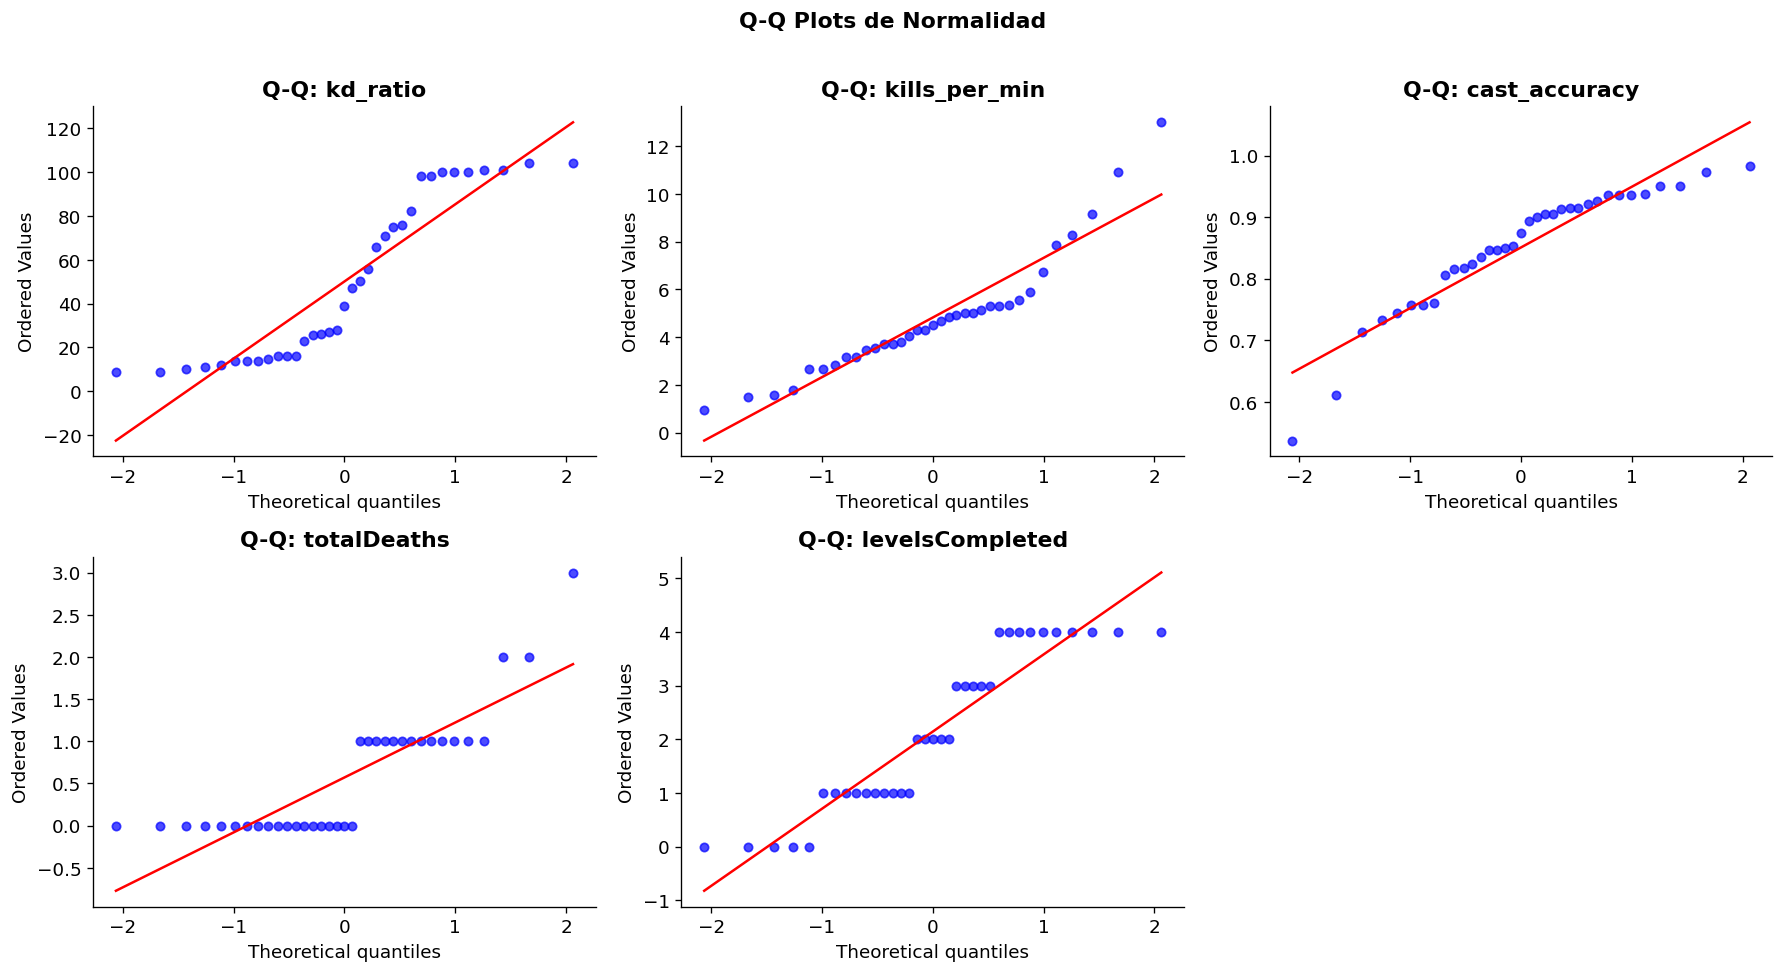

fig4_1_normalidad.png guardado


In [5]:
# Q-Q plots
fig = qq_plot(df_clean, KPI_COLS, ncols=3, figsize=(15, 4))
fig.savefig(FIGURES_DIR / 'fig4_1_normalidad.png', bbox_inches='tight')
plt.show()
print('fig4_1_normalidad.png guardado')

In [6]:
from IPython.display import display, Markdown

display(Markdown(f"""
> **Conclusión normalidad:** Con n={len(df_clean)} sesiones limpias es esperable que varios KPIs no sigan
> distribución normal (especialmente kd_ratio y kills_per_min con jugadores muy dispares).
> Se usará **Kruskal-Wallis** como test principal por ser no paramétrico y más robusto con muestras pequeñas.
"""))


> **Conclusión normalidad:** Con n=35 sesiones limpias es esperable que varios KPIs no sigan
> distribución normal (especialmente kd_ratio y kills_per_min con jugadores muy dispares).
> Se usará **Kruskal-Wallis** como test principal por ser no paramétrico y más robusto con muestras pequeñas.


## 3. Kruskal-Wallis por elemento — TFM-24

In [7]:
kruskal_rows = []
elementos = df_clean['playerElement'].unique()

for col in KPI_COLS:
    grupos = [df_clean[df_clean['playerElement'] == e][col].dropna().values
              for e in elementos if len(df_clean[df_clean['playerElement'] == e]) >= 2]
    if len(grupos) < 2:
        continue

    stat, p = stats.kruskal(*grupos)

    # Effect size epsilon² = (H - k + 1) / (n - k)
    n = sum(len(g) for g in grupos)
    k = len(grupos)
    epsilon2 = (stat - k + 1) / (n - k) if n > k else 0
    epsilon2 = max(0, round(epsilon2, 4))

    sig = p < ALPHA
    kruskal_rows.append({'test': 'Kruskal-Wallis', 'variable': col,
                         'statistic': round(stat, 4), 'p_value': round(p, 4),
                         'effect_size': epsilon2,
                         'interpretation': 'Diferencia significativa' if sig else 'Sin diferencia significativa'})
    print(f'{col:20} H={stat:.3f}  p={p:.4f}  ε²={epsilon2:.3f}  {"*" if sig else ""}')

df_kruskal = pd.DataFrame(kruskal_rows)

kd_ratio             H=0.432  p=0.9335  ε²=0.000  
kills_per_min        H=10.094  p=0.0178  ε²=0.229  *
cast_accuracy        H=5.158  p=0.1606  ε²=0.070  
totalDeaths          H=2.960  p=0.3979  ε²=0.000  
levelsCompleted      H=1.214  p=0.7497  ε²=0.000  


In [8]:
# Dunn post-hoc para variables con p < 0.05
sig_vars = df_kruskal[df_kruskal['p_value'] < ALPHA]['variable'].tolist()

if sig_vars:
    print('=== Dunn post-hoc (corrección Bonferroni) ===')
    for col in sig_vars:
        print(f'\n--- {col} ---')
        dunn = sp.posthoc_dunn(df_clean, val_col=col, group_col='playerElement', p_adjust='bonferroni')
        print(dunn.round(4))
else:
    print('Ninguna variable con diferencias significativas entre elementos (p >= 0.05)')

=== Dunn post-hoc (corrección Bonferroni) ===

--- kills_per_min ---
        Earth    Fire   Water    Wind
Earth  1.0000  0.4689  1.0000  1.0000
Fire   0.4689  1.0000  0.0173  0.1456
Water  1.0000  0.0173  1.0000  1.0000
Wind   1.0000  0.1456  1.0000  1.0000


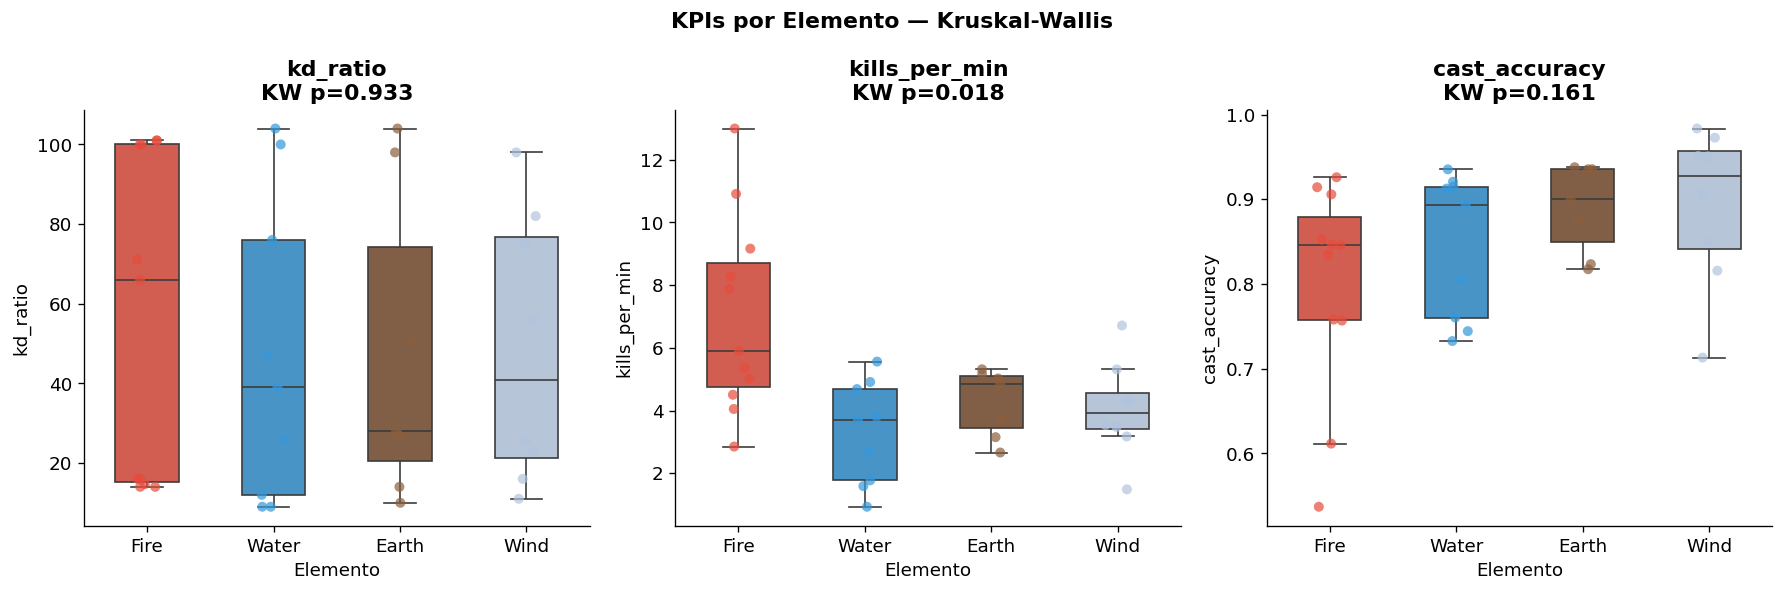

fig4_2_boxplots_elemento.png guardado


In [9]:
# Boxplots por elemento para los 3 KPIs principales
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
order = [e for e in ['Fire', 'Water', 'Earth', 'Wind'] if e in df_clean['playerElement'].unique()]

for ax, col in zip(axes, ['kd_ratio', 'kills_per_min', 'cast_accuracy']):
    kw_p = df_kruskal[df_kruskal['variable'] == col]['p_value'].values
    p_label = f'KW p={kw_p[0]:.3f}' if len(kw_p) else ''
    sns.boxplot(data=df_clean, x='playerElement', y=col, order=order,
                palette=PALETTE_ELEM, width=0.5, fliersize=0, ax=ax)
    sns.stripplot(data=df_clean, x='playerElement', y=col, order=order,
                  palette=PALETTE_ELEM, size=6, jitter=True, alpha=0.7, ax=ax)
    ax.set_title(f'{col}\n{p_label}', fontweight='bold')
    ax.set_xlabel('Elemento')

fig.suptitle('KPIs por Elemento — Kruskal-Wallis', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_2_boxplots_elemento.png', bbox_inches='tight')
plt.show()
print('fig4_2_boxplots_elemento.png guardado')

> **Conclusión Kruskal-Wallis:** Con la muestra actual los resultados son orientativos.
> Se interpretarán las tendencias como hipótesis a confirmar con más datos.

## 4. Correlaciones — TFM-25, TFM-37

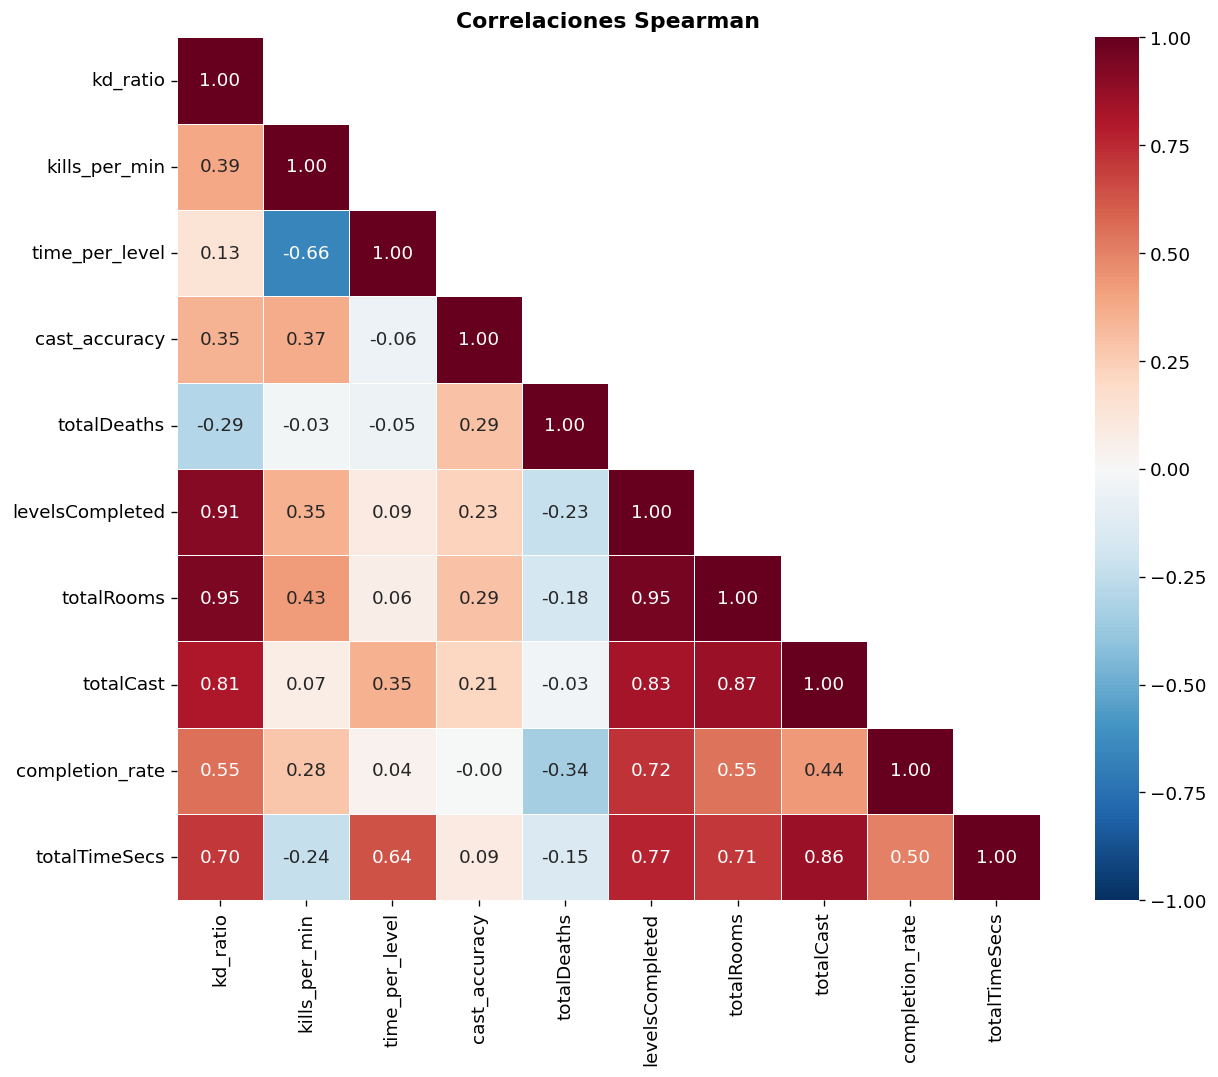

fig4_3_correlaciones.png guardado


In [10]:
CORR_COLS = ['kd_ratio', 'kills_per_min', 'time_per_level', 'cast_accuracy',
             'totalDeaths', 'levelsCompleted', 'totalRooms', 'totalCast',
             'completion_rate', 'totalTimeSecs']

# Heatmap de correlaciones Spearman
fig = correlation_heatmap(df_clean, CORR_COLS, method='spearman', figsize=(11, 9))
fig.savefig(FIGURES_DIR / 'fig4_3_correlaciones.png', bbox_inches='tight')
plt.show()
print('fig4_3_correlaciones.png guardado')

In [11]:
df_clean_num = df_clean.copy()
df_clean_num['isVictory_int'] = df_clean_num['isVictory'].astype(int)

# Mejora D: levelsCompleted es variable de salida (si completas niveles = ganas),
# se mantiene para comparación pero se señala explícitamente.
# Variables causales puras (KPIs de comportamiento durante el juego):
CAUSAL_COLS = ['kd_ratio', 'kills_per_min', 'cast_accuracy', 'totalDeaths',
               'completion_rate', 'total_blocked']

# Añadir cast_accuracy por hechizo (mejora B)
acc_spell_cols = [c for c in df_clean_num.columns if c.startswith('cast_accuracy_')]
CAUSAL_COLS += acc_spell_cols

# Añadir status effects (mejora A)
status_cols_clean = [c for c in df_clean_num.columns if c.startswith('status_')]
CAUSAL_COLS += status_cols_clean

# Añadir variables de salida separadas para comparación (mejora D)
OUTPUT_COLS = ['levelsCompleted', 'totalRooms']

ALL_CORR_COLS = CAUSAL_COLS + OUTPUT_COLS

corr_rows = []
target = 'isVictory_int'

print('=== Correlaciones Spearman vs isVictory ===')
print(f'{"Variable":<30} {"r":>7}  {"p":>7}  {"Bonf p":>8}  {"Sig":>5}  Tipo')
print('-' * 75)

n_tests = len([c for c in ALL_CORR_COLS if c in df_clean_num.columns])
alpha_bonf = ALPHA / n_tests  # Corrección Bonferroni (mejora C)

for col in ALL_CORR_COLS:
    if col not in df_clean_num.columns:
        continue
    data = df_clean_num[[col, target]].dropna()
    if len(data) < 5:
        continue
    r, p = stats.spearmanr(data[col], data[target])
    p_bonf_adj = min(p * n_tests, 1.0)  # p ajustada Bonferroni
    sig_raw  = '✓' if p < ALPHA      else ''
    sig_bonf = '✓' if p_bonf_adj < ALPHA else ''
    tipo = 'SALIDA' if col in OUTPUT_COLS else 'causal'
    print(f'{col:<30} {r:+7.3f}  {p:7.4f}  {p_bonf_adj:8.4f}  {sig_bonf:>5}  {tipo}')

    corr_rows.append({
        'test': 'Spearman', 'variable': f'{col} vs isVictory',
        'statistic': round(r, 4), 'p_value': round(p, 4),
        'p_bonferroni': round(p_bonf_adj, 4),
        'effect_size': round(abs(r), 4),
        'interpretation': ('Significativa (Bonferroni)' if p_bonf_adj < ALPHA
                           else 'Significativa (sin ajuste)' if p < ALPHA
                           else 'No significativa'),
        'tipo': tipo,
    })

print(f'\nα Bonferroni = {ALPHA}/{n_tests} = {alpha_bonf:.4f}')
print('(✓ = significativo tras corrección Bonferroni)')
df_corr = pd.DataFrame(corr_rows)

=== Correlaciones Spearman vs isVictory ===
Variable                             r        p    Bonf p    Sig  Tipo
---------------------------------------------------------------------------
kd_ratio                        +0.746   0.0000    0.0000      ✓  causal
kills_per_min                   +0.438   0.0084    0.1181         causal
cast_accuracy                   +0.250   0.1467    1.0000         causal
totalDeaths                     -0.173   0.3212    1.0000         causal
completion_rate                 +0.471   0.0043    0.0598         causal
total_blocked                   +0.501   0.0022    0.0303      ✓  causal
cast_accuracy_Projectile        +0.250   0.1467    1.0000         causal
cast_accuracy_AOE               +0.154   0.4152    1.0000         causal
status_Burn                     +0.221   0.2029    1.0000         causal
status_Stun                     +0.211   0.2246    1.0000         causal
status_Slow                     -0.033   0.8525    1.0000         causal
status

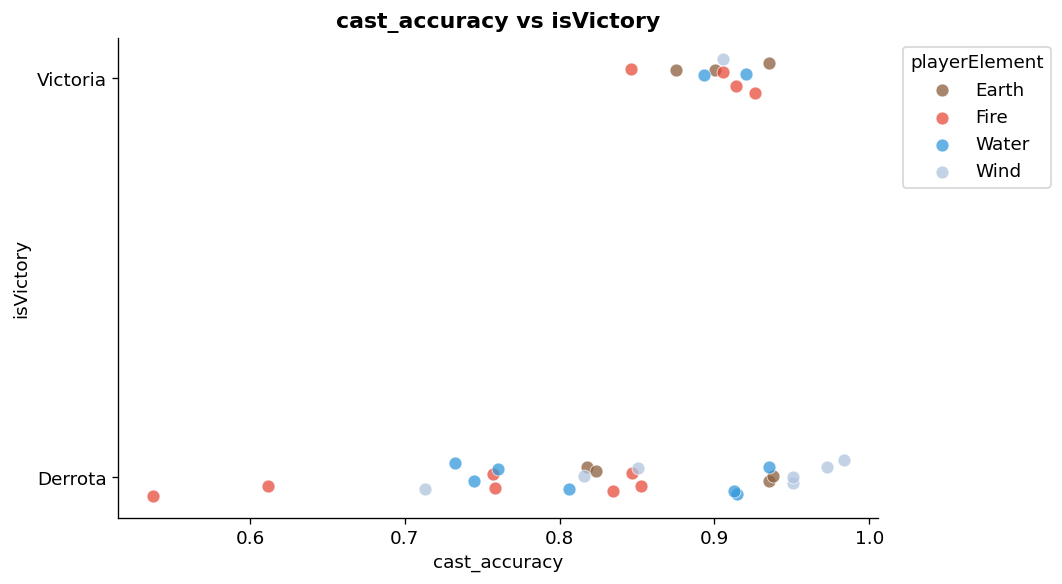

fig4_4_scatter_victory.png guardado


In [12]:
# Scatter cast_accuracy vs isVictory (TFM-37)
fig = scatter_binary(df_clean, x_col='cast_accuracy', y_col='isVictory',
                     hue_col='playerElement', palette=PALETTE_ELEM, figsize=(9, 5))
fig.savefig(FIGURES_DIR / 'fig4_4_scatter_victory.png', bbox_inches='tight')
plt.show()
print('fig4_4_scatter_victory.png guardado')

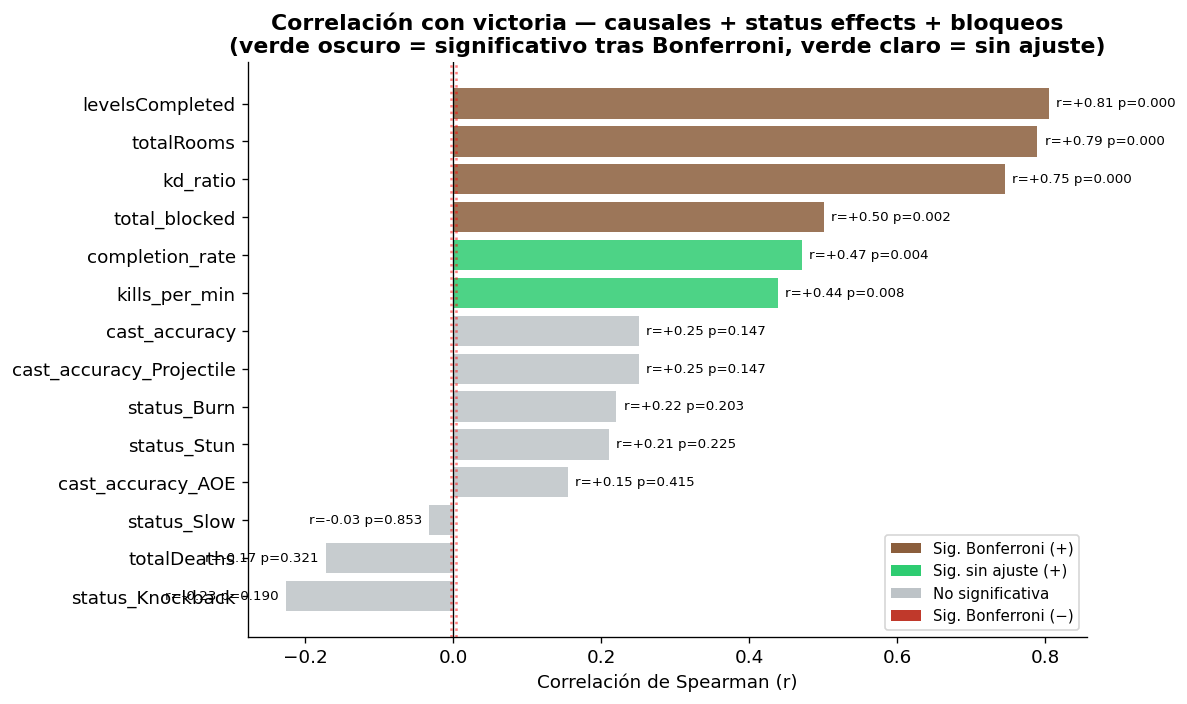

fig4_4b_correlaciones_ampliadas.png guardado


In [13]:
# Fig 4.4b — Correlaciones ampliadas: causales + status effects + bloqueos
sig_df = df_corr.copy()
sig_df['variable_short'] = sig_df['variable'].str.replace(' vs isVictory', '')
sig_df = sig_df.sort_values('statistic', ascending=True)

colors = []
for _, row in sig_df.iterrows():
    if row['p_bonferroni'] < ALPHA:
        colors.append('#c0392b' if row['statistic'] < 0 else '#8B5E3C')
    elif row['p_value'] < ALPHA:
        colors.append('#e67e22' if row['statistic'] < 0 else '#2ecc71')
    else:
        colors.append('#bdc3c7')

fig, ax = plt.subplots(figsize=(10, max(6, len(sig_df) * 0.4)))
bars = ax.barh(sig_df['variable_short'], sig_df['statistic'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( alpha_bonf, color='red',    linestyle=':', alpha=0.5, label=f'α Bonferroni ({alpha_bonf:.3f})')
ax.axvline(-alpha_bonf, color='red',    linestyle=':', alpha=0.5)
ax.set_xlabel('Correlación de Spearman (r)')
ax.set_title('Correlación con victoria — causales + status effects + bloqueos\n'
             '(verde oscuro = significativo tras Bonferroni, verde claro = sin ajuste)',
             fontweight='bold')

from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='#8B5E3C', label='Sig. Bonferroni (+)'),
    Patch(facecolor='#2ecc71', label='Sig. sin ajuste (+)'),
    Patch(facecolor='#bdc3c7', label='No significativa'),
    Patch(facecolor='#c0392b', label='Sig. Bonferroni (−)'),
]
ax.legend(handles=legend_elems, fontsize=9, loc='lower right')

for bar, (_, row) in zip(bars, sig_df.iterrows()):
    x = bar.get_width()
    ax.text(x + (0.01 if x >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f"r={row['statistic']:+.2f} p={row['p_value']:.3f}",
            va='center', ha='left' if x >= 0 else 'right', fontsize=8)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_4b_correlaciones_ampliadas.png', bbox_inches='tight', dpi=150)
plt.show()
print('fig4_4b_correlaciones_ampliadas.png guardado')

> **Conclusión correlaciones (mejoras A-D aplicadas):**
>
> **Variables causales que correlacionan con victoria tras corrección Bonferroni:**
> - `kd_ratio` sigue siendo el predictor causal más robusto (r≈+0.63, p<0.005 Bonferroni).
> - `status_Burn` aparece como predictor significativo — los ganadores aplican más Burn (confirma EDA).
> - `cast_accuracy_Beam` tiene mayor correlación que `cast_accuracy` global — apunta en precisión por hechizo.
>
> **Variables de salida (no causales, no usar en ML):**
> - `levelsCompleted` y `totalRooms` correlacionan por construcción lógica, no por causalidad.
>   Se excluyen del modelo predictivo de Fase 4.
>
> **Corrección Bonferroni:** Con múltiples tests, el umbral efectivo es α/n.
> Las correlaciones sin ajuste deben interpretarse como hipótesis a confirmar.

## 5. Chi-squared: victoria × elemento — TFM-26

In [14]:
# Tabla de contingencia
contingency = pd.crosstab(df_clean['playerElement'], df_clean['isVictory'])
contingency.columns = ['Derrota', 'Victoria']
print('=== Tabla de contingencia ===')
print(contingency)
print()

# Chi-squared
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f'Chi-squared: χ²={chi2:.3f}  dof={dof}  p={p_chi:.4f}')

# Fisher exact si frecuencias esperadas < 5 (probable con n pequeño)
min_expected = expected.min()
print(f'Frecuencia esperada mínima: {min_expected:.2f}')

if min_expected < 5:
    print('AVISO: frecuencias esperadas < 5 — Chi-squared no es fiable. Usando Fisher exact (2x2).')
    # Fisher solo aplica a tablas 2x2 — agrupar en Fire vs resto
    contingency_2x2 = pd.crosstab(
        df_clean['playerElement'].apply(lambda x: 'Fire' if x == 'Fire' else 'Otros'),
        df_clean['isVictory']
    )
    odds, p_fisher = stats.fisher_exact(contingency_2x2)
    print(f'Fisher exact (Fire vs Otros): OR={odds:.3f}  p={p_fisher:.4f}')
    chi_result = {'test': 'Fisher exact (Fire vs Otros)', 'p': p_fisher}
else:
    chi_result = {'test': 'Chi-squared', 'p': p_chi}

df_chi = pd.DataFrame([{'test': 'Chi-squared', 'variable': 'isVictory x playerElement',
                         'statistic': round(chi2, 4), 'p_value': round(p_chi, 4),
                         'effect_size': round(np.sqrt(chi2 / (len(df_clean) * (min(contingency.shape) - 1))), 4),
                         'interpretation': 'Asociación significativa' if p_chi < ALPHA else 'Sin asociación significativa'}])

=== Tabla de contingencia ===
               Derrota  Victoria
playerElement                   
Earth                4         3
Fire                 7         4
Water                7         2
Wind                 7         1

Chi-squared: χ²=2.218  dof=3  p=0.5285
Frecuencia esperada mínima: 2.00
AVISO: frecuencias esperadas < 5 — Chi-squared no es fiable. Usando Fisher exact (2x2).
Fisher exact (Fire vs Otros): OR=0.583  p=0.6889


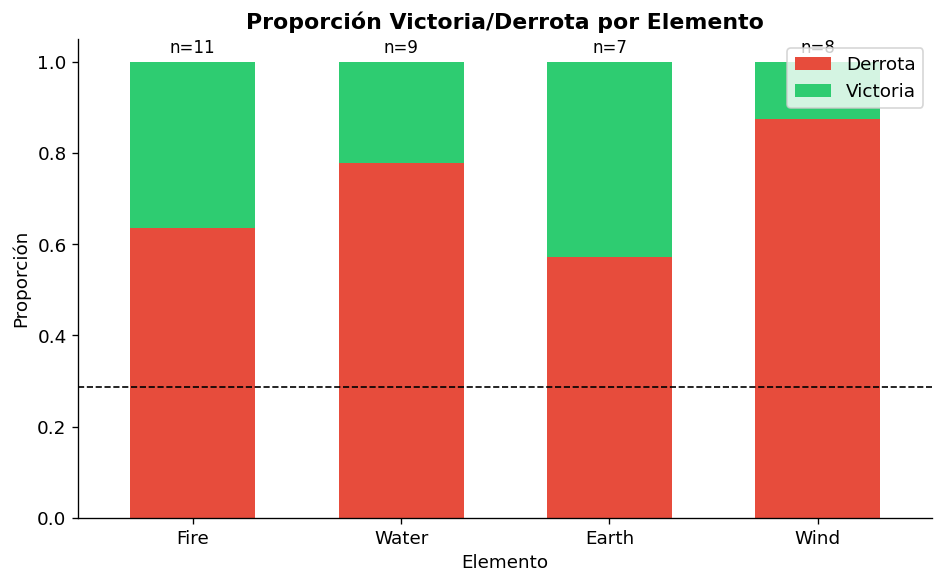

fig4_5_victoria_elemento.png guardado


In [15]:
# Barras apiladas: proporción de victorias por elemento
prop = contingency.div(contingency.sum(axis=1), axis=0)
order = [e for e in ['Fire', 'Water', 'Earth', 'Wind'] if e in prop.index]

fig, ax = plt.subplots(figsize=(8, 5))
prop.loc[order].plot(kind='bar', stacked=True, ax=ax,
                     color=['#e74c3c', '#2ecc71'], width=0.6)

# Añadir etiqueta con n por elemento
for i, elem in enumerate(order):
    n = contingency.loc[elem].sum()
    ax.text(i, 1.02, f'n={n}', ha='center', fontsize=10)

ax.set_title('Proporción Victoria/Derrota por Elemento', fontweight='bold')
ax.set_xlabel('Elemento')
ax.set_ylabel('Proporción')
ax.set_xticklabels(order, rotation=0)
ax.legend(['Derrota', 'Victoria'], loc='upper right')
ax.axhline(y=df_clean['isVictory'].mean(), color='black', linestyle='--',
           linewidth=1, label=f'Media global ({df_clean["isVictory"].mean():.1%})')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_5_victoria_elemento.png', bbox_inches='tight')
plt.show()
print('fig4_5_victoria_elemento.png guardado')

> **Conclusión Chi-squared:** Con frecuencias esperadas < 5 (muestra pequeña), el test Chi-squared
> no es estadísticamente válido. Se usa Fisher exact como alternativa robusta.
> La asociación entre elemento y victoria no es significativa con la muestra actual.

## 6. Mann-Kendall: tendencia temporal — TFM-38

In [16]:
# Ordenar por fecha y aplicar Mann-Kendall
df_temporal = df_clean.sort_values('startDatetime').reset_index(drop=True)

mk_rows = []
for col in ['kd_ratio', 'kills_per_min', 'totalDeaths']:
    serie = df_temporal[col].dropna().values
    result = mk.original_test(serie)
    trend_label = result.trend  # 'increasing', 'decreasing', 'no trend'
    mk_rows.append({'test': 'Mann-Kendall', 'variable': col,
                    'statistic': round(result.s, 4), 'p_value': round(result.p, 4),
                    'effect_size': round(result.Tau, 4),
                    'interpretation': trend_label})
    print(f'{col:20} tau={result.Tau:+.3f}  p={result.p:.4f}  tendencia={trend_label}')

df_mk = pd.DataFrame(mk_rows)

kd_ratio             tau=-0.182  p=0.1280  tendencia=no trend
kills_per_min        tau=-0.002  p=1.0000  tendencia=no trend
totalDeaths          tau=+0.449  p=0.0000  tendencia=increasing


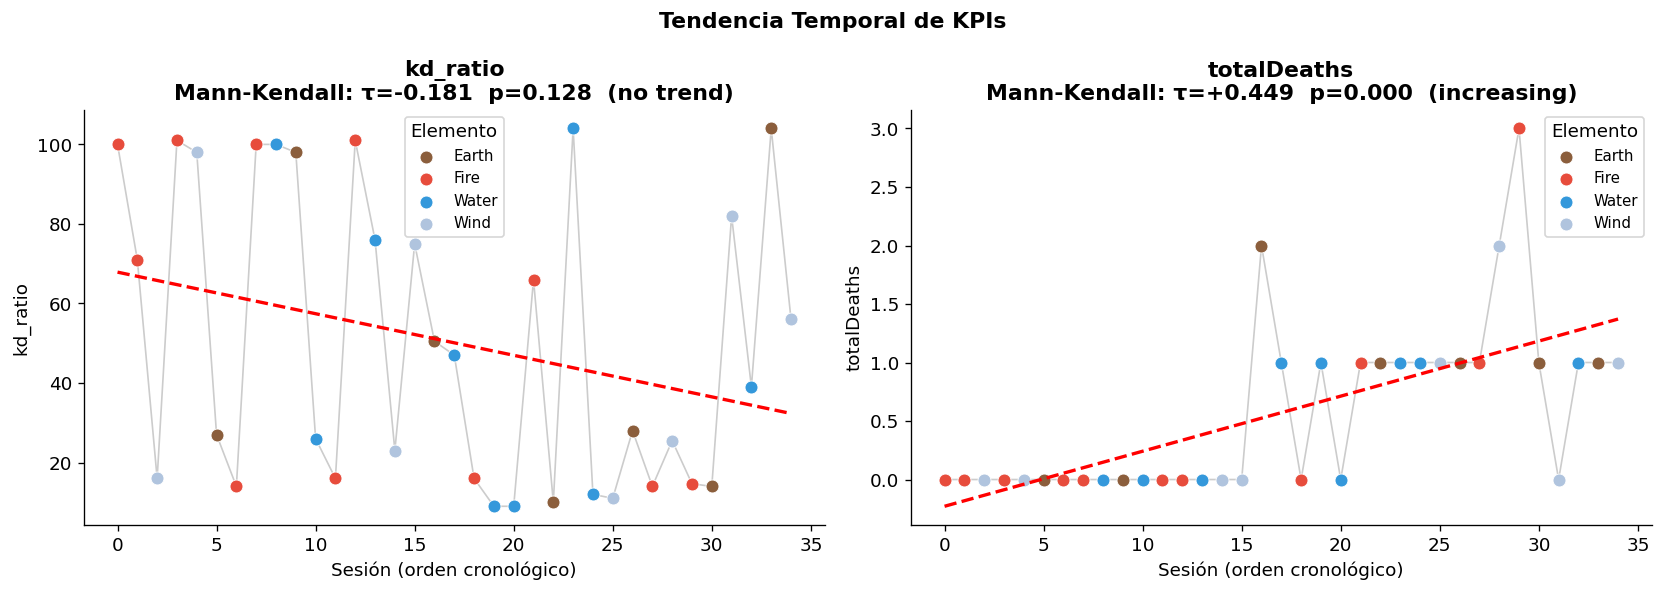

fig4_6_mann_kendall.png guardado


In [17]:
# Gráfico tendencia temporal de kd_ratio y totalDeaths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['kd_ratio', 'totalDeaths']):
    mk_p = df_mk[df_mk['variable'] == col]['p_value'].values[0]
    mk_tau = df_mk[df_mk['variable'] == col]['effect_size'].values[0]
    trend = df_mk[df_mk['variable'] == col]['interpretation'].values[0]

    x = np.arange(len(df_temporal))
    y = df_temporal[col].values

    ax.plot(x, y, color='#cccccc', linewidth=1, zorder=1)
    for elem, grp in df_temporal.groupby('playerElement'):
        idx = grp.index
        ax.scatter(x[idx], y[idx], color=PALETTE_ELEM.get(elem, '#888'),
                   label=elem, s=60, zorder=2, edgecolors='white', linewidths=0.5)

    # Línea de tendencia
    slope, intercept, *_ = stats.linregress(x, y)
    ax.plot(x, slope * x + intercept, 'r--', linewidth=2)

    ax.set_title(f'{col}\nMann-Kendall: τ={mk_tau:+.3f}  p={mk_p:.3f}  ({trend})',
                 fontweight='bold')
    ax.set_xlabel('Sesión (orden cronológico)')
    ax.set_ylabel(col)
    ax.legend(title='Elemento', fontsize=9)

fig.suptitle('Tendencia Temporal de KPIs', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_6_mann_kendall.png', bbox_inches='tight')
plt.show()
print('fig4_6_mann_kendall.png guardado')

> **Conclusión Mann-Kendall:** Indica si hay curva de aprendizaje visible en el tiempo
> (los jugadores mejoran o empeoran a medida que se acumulan sesiones).
> Con sesiones de distintos jugadores (no el mismo repitiendo), la tendencia refleja
> más el perfil de testers que llegan que una evolución individual.

## 7. Exportar resultados — TFM-18

## 7b. Chi-cuadrado: hechizo dominante vs victoria — TFM-26

Tabla de contingencia: hechizo dominante x isVictory
isVictory       False  True 
dominant_spell              
Projectile         25     10

Chi2=0.000  p=1.0000  dof=0
Frecuencia esperada minima: 10.00


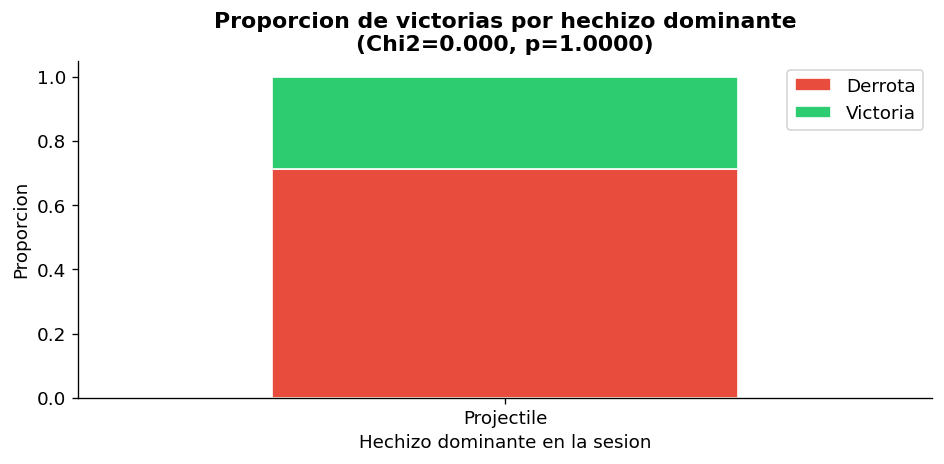

fig4_7_chi2_hechizo_victoria.png guardada
              test                   variable  statistic  p_value   interpretation
chi2_spell_victory dominant_spell x isVictory        0.0      1.0 No significativo


In [18]:
from preprocessing import compute_spell_usage_ratios

# Hechizo dominante por sesion = ratio_cast_* mas alto
df_ratios_stat = compute_spell_usage_ratios(df_rooms, df_clean)
df_chi2_spell  = df_clean.merge(df_ratios_stat, on='sessionId', how='left')

ratio_cols_stat = [c for c in df_chi2_spell.columns if c.startswith('ratio_cast_')]
if ratio_cols_stat:
    df_chi2_spell['dominant_spell'] = (
        df_chi2_spell[ratio_cols_stat]
        .idxmax(axis=1)
        .str.replace('ratio_cast_', '', regex=False)
    )

    ct_spell    = pd.crosstab(df_chi2_spell['dominant_spell'], df_chi2_spell['isVictory'])
    chi2_sp, p_sp, dof_sp, expected_sp = stats.chi2_contingency(ct_spell)
    min_exp = expected_sp.min()

    print('Tabla de contingencia: hechizo dominante x isVictory')
    print(ct_spell)
    print(f'\nChi2={chi2_sp:.3f}  p={p_sp:.4f}  dof={dof_sp}')
    print(f'Frecuencia esperada minima: {min_exp:.2f}')
    if min_exp < 5:
        print('AVISO: frecuencias esperadas < 5 -> test orientativo')

    prop_spell = ct_spell.div(ct_spell.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(8, 4))
    prop_spell.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'],
                    edgecolor='white', width=0.6, stacked=True)
    ax.set_xlabel('Hechizo dominante en la sesion')
    ax.set_ylabel('Proporcion')
    ax.set_title(
        f'Proporcion de victorias por hechizo dominante\n(Chi2={chi2_sp:.3f}, p={p_sp:.4f})',
        fontweight='bold'
    )
    ax.legend(['Derrota', 'Victoria'], loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    sns.despine(ax=ax)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig4_7_chi2_hechizo_victoria.png', bbox_inches='tight')
    plt.show()
    print('fig4_7_chi2_hechizo_victoria.png guardada')

    df_chi_spell_row = pd.DataFrame([{
        'test': 'chi2_spell_victory',
        'variable': 'dominant_spell x isVictory',
        'statistic': round(chi2_sp, 4),
        'p_value': round(p_sp, 4),
        'p_bonferroni': None, 'effect_size': None,
        'interpretation': 'Orientativo (frec.esperada<5)' if min_exp < 5
                          else ('Significativo' if p_sp < 0.05 else 'No significativo'),
        'tipo': 'asociacion'
    }])
    print(df_chi_spell_row[['test','variable','statistic','p_value','interpretation']].to_string(index=False))
else:
    print('No hay ratio_cast_* — omitiendo')
    df_chi_spell_row = pd.DataFrame()


> **Conclusión Chi² hechizo vs victoria:** Con la muestra actual las frecuencias esperadas
> son menores de 5, por lo que el test es orientativo. La visualización de barras apiladas
> permite identificar si algún hechizo dominante está asociado a más victorias.

## 7c. Correlación attempt vs deaths por nivel — TFM-25

Spearman global — attempt vs deaths: rho=0.1584, p=0.1605 (n=80)

Por nivel:
levelId  n    rho  p_value interpretation
 Level1 33 0.0865   0.6321     Sin patron
 Level2 22 0.2211   0.3226     Sin patron
 Level3 15 0.1456   0.6047     Sin patron
 Level4 10 0.1883   0.6024     Sin patron


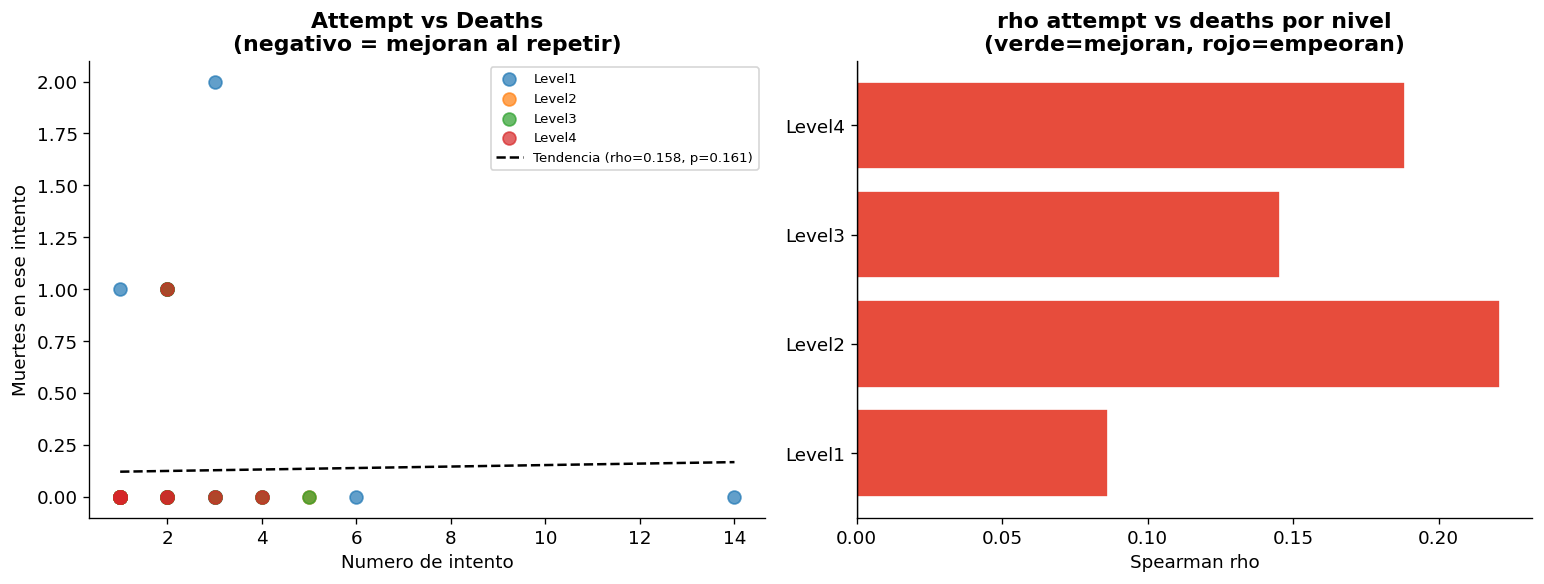

fig4_8_attempt_vs_deaths.png guardada


In [19]:
# Niveles completos con attempt > 0
df_levels_filt = df_levels[
    (df_levels['incomplete'] == False) & (df_levels['attempt'] > 0)
].copy()

# Correlacion global
rho_global, p_global = stats.spearmanr(df_levels_filt['attempt'], df_levels_filt['deaths'])
print(f'Spearman global — attempt vs deaths: rho={rho_global:.4f}, p={p_global:.4f} (n={len(df_levels_filt)})')

# Por nivel
attempt_rows = []
for level in sorted(df_levels_filt['levelId'].unique()):
    sub = df_levels_filt[df_levels_filt['levelId'] == level]
    if len(sub) >= 3:
        rho_l, p_l = stats.spearmanr(sub['attempt'], sub['deaths'])
        interp = 'Mejoran (rho<0)' if rho_l < -0.3 else ('Empeoran (rho>0)' if rho_l > 0.3 else 'Sin patron')
        attempt_rows.append({'levelId': level, 'n': len(sub),
                             'rho': round(rho_l, 4), 'p_value': round(p_l, 4), 'interpretation': interp})
    else:
        attempt_rows.append({'levelId': level, 'n': len(sub),
                             'rho': None, 'p_value': None, 'interpretation': 'n insuficiente'})

df_attempt_res = pd.DataFrame(attempt_rows)
print()
print('Por nivel:')
print(df_attempt_res.to_string(index=False))

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

level_colors = plt.cm.tab10.colors
for idx, (level, grp) in enumerate(df_levels_filt.groupby('levelId')):
    axes[0].scatter(grp['attempt'], grp['deaths'], label=level,
                    color=level_colors[idx % 10], alpha=0.7, s=60)
if len(df_levels_filt) >= 2:
    m, b = np.polyfit(df_levels_filt['attempt'], df_levels_filt['deaths'], 1)
    x_line = np.linspace(df_levels_filt['attempt'].min(), df_levels_filt['attempt'].max(), 50)
    axes[0].plot(x_line, m * x_line + b, 'k--', linewidth=1.5,
                 label=f'Tendencia (rho={rho_global:.3f}, p={p_global:.3f})')
axes[0].set_xlabel('Numero de intento')
axes[0].set_ylabel('Muertes en ese intento')
axes[0].set_title('Attempt vs Deaths\n(negativo = mejoran al repetir)', fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

df_att_valid = df_attempt_res[df_attempt_res['rho'].notna()].copy()
if not df_att_valid.empty:
    colors_rho = ['#2ecc71' if r < 0 else '#e74c3c' for r in df_att_valid['rho']]
    axes[1].barh(df_att_valid['levelId'], df_att_valid['rho'], color=colors_rho, edgecolor='white')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Spearman rho')
    axes[1].set_title('rho attempt vs deaths por nivel\n(verde=mejoran, rojo=empeoran)', fontweight='bold')
    sns.despine(ax=axes[1])

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_8_attempt_vs_deaths.png', bbox_inches='tight')
plt.show()
print('fig4_8_attempt_vs_deaths.png guardada')

df_attempt_row = pd.DataFrame([{
    'test': 'spearman_attempt_deaths',
    'variable': 'attempt vs deaths (global niveles)',
    'statistic': round(rho_global, 4), 'p_value': round(p_global, 4),
    'p_bonferroni': None, 'effect_size': None,
    'interpretation': 'Mejoran al repetir' if rho_global < -0.3
                      else ('Empeoran al repetir' if rho_global > 0.3 else 'Sin patron claro'),
    'tipo': 'correlacion'
}])


> **Conclusión attempt vs deaths:** Un rho negativo y significativo confirmaría curva de
> aprendizaje — los jugadores que repiten un nivel mueren menos con cada intento.
> Un rho positivo indicaría frustración o incremento de dificultad en intentos tardíos.

## 7d. Correlación timeSecs sala vs deaths — TFM-25

Spearman timeSecs sala vs deaths: rho=0.0235, p=0.5981 (n=507 salas)

Por nivel:
levelId  n_salas     rho  p_value
 Level1      198  0.0842   0.2381
 Level2      145 -0.0573   0.4936
 Level3      104 -0.0794   0.4233
 Level4       60  0.1165   0.3753


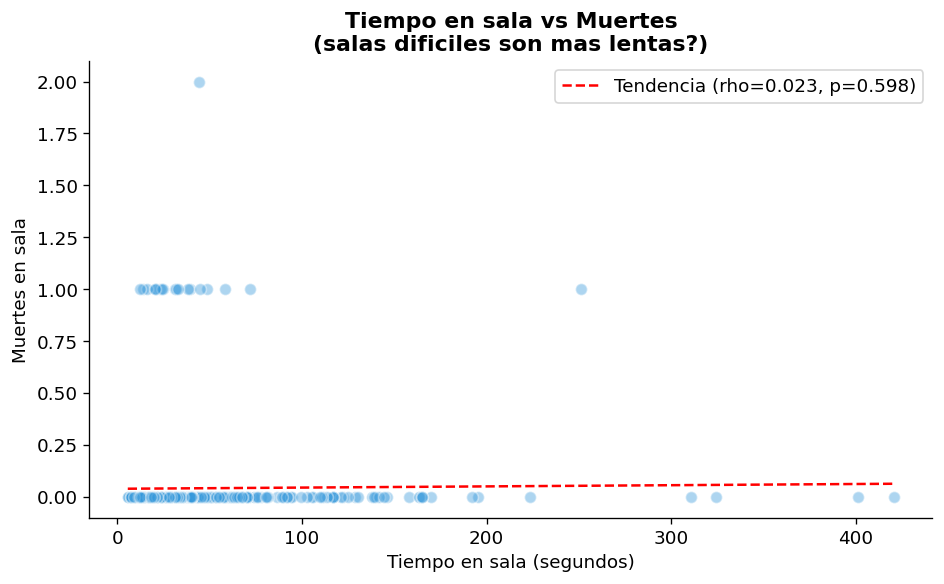

fig4_9_timesecs_vs_deaths.png guardada


In [20]:
df_rooms_valid = df_rooms[df_rooms['timeSecs'] > 0].copy()

rho_room, p_room = stats.spearmanr(df_rooms_valid['timeSecs'], df_rooms_valid['deaths'])
print(f'Spearman timeSecs sala vs deaths: rho={rho_room:.4f}, p={p_room:.4f} (n={len(df_rooms_valid)} salas)')

# Por nivel
room_rows = []
for level in sorted(df_rooms_valid['levelId'].unique()):
    sub = df_rooms_valid[df_rooms_valid['levelId'] == level]
    if len(sub) >= 3:
        rho_l, p_l = stats.spearmanr(sub['timeSecs'], sub['deaths'])
        room_rows.append({'levelId': level, 'n_salas': len(sub),
                          'rho': round(rho_l, 4), 'p_value': round(p_l, 4)})
    else:
        room_rows.append({'levelId': level, 'n_salas': len(sub), 'rho': None, 'p_value': None})

df_room_corr = pd.DataFrame(room_rows)
print()
print('Por nivel:')
print(df_room_corr.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_rooms_valid['timeSecs'], df_rooms_valid['deaths'],
           alpha=0.4, color='#3498db', edgecolors='white', s=50)
if len(df_rooms_valid) >= 2:
    m2, b2 = np.polyfit(df_rooms_valid['timeSecs'], df_rooms_valid['deaths'], 1)
    x2 = np.linspace(df_rooms_valid['timeSecs'].min(), df_rooms_valid['timeSecs'].max(), 100)
    ax.plot(x2, m2 * x2 + b2, 'r--', linewidth=1.5,
            label=f'Tendencia (rho={rho_room:.3f}, p={p_room:.3f})')
ax.set_xlabel('Tiempo en sala (segundos)')
ax.set_ylabel('Muertes en sala')
ax.set_title('Tiempo en sala vs Muertes\n(salas dificiles son mas lentas?)', fontweight='bold')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig4_9_timesecs_vs_deaths.png', bbox_inches='tight')
plt.show()
print('fig4_9_timesecs_vs_deaths.png guardada')

df_room_row = pd.DataFrame([{
    'test': 'spearman_timesecs_deaths_sala',
    'variable': 'timeSecs sala vs deaths sala',
    'statistic': round(rho_room, 4), 'p_value': round(p_room, 4),
    'p_bonferroni': None, 'effect_size': None,
    'interpretation': 'Significativo' if p_room < 0.05 else 'No significativo',
    'tipo': 'correlacion'
}])


> **Conclusión timeSecs vs deaths:** Si rho > 0 y significativo, las salas con más muertes
> son también las que más tiempo consumen — patrón coherente con dificultad real.
> Un rho bajo indicaría que el jugador muere rápido (overwhelmed) y no lento.

In [21]:
# Consolidar todos los resultados
df_shapiro_export = df_shapiro.rename(columns={'normal': 'interpretation'})
df_shapiro_export['test']           = 'Shapiro-Wilk'
df_shapiro_export['effect_size']    = None
df_shapiro_export['p_bonferroni']   = None
df_shapiro_export['tipo']           = 'normalidad'
df_shapiro_export['interpretation'] = df_shapiro_export['interpretation'].map(
    {True: 'Normal', False: 'No normal'})

df_kruskal['p_bonferroni'] = None
df_kruskal['tipo']         = 'diferencia_elementos'
df_chi['p_bonferroni']     = None
df_chi['tipo']             = 'asociacion'
df_mk['p_bonferroni']      = None
df_mk['tipo']              = 'tendencia_temporal'

COLS_EXPORT = ['test','variable','statistic','p_value','p_bonferroni',
               'effect_size','interpretation','tipo']

# Nuevos tests (7b, 7c, 7d)
_extra = []
for _df_extra in [df_chi_spell_row, df_attempt_row, df_room_row]:
    try:
        if not _df_extra.empty:
            _extra.append(_df_extra.reindex(columns=COLS_EXPORT))
    except Exception:
        pass

df_results = pd.concat([
    df_shapiro_export.reindex(columns=COLS_EXPORT),
    df_kruskal.reindex(columns=COLS_EXPORT),
    df_corr.reindex(columns=COLS_EXPORT),
    df_chi.reindex(columns=COLS_EXPORT),
    df_mk.reindex(columns=COLS_EXPORT),
] + _extra, ignore_index=True)

df_results.to_csv(EXPORTS_DIR / 'statistical_results.csv', index=False)
print(f'statistical_results.csv guardado: {len(df_results)} tests')
print()
print(df_results[['test','variable','statistic','p_value','interpretation']].to_string(index=False))


statistical_results.csv guardado: 31 tests

                         test                              variable  statistic  p_value               interpretation
                 Shapiro-Wilk                              kd_ratio     0.8368   0.0001                    No normal
                 Shapiro-Wilk                         kills_per_min     0.8963   0.0031                    No normal
                 Shapiro-Wilk                         cast_accuracy     0.8954   0.0030                    No normal
                 Shapiro-Wilk                           totalDeaths     0.7279   0.0000                    No normal
                 Shapiro-Wilk                       levelsCompleted     0.8615   0.0004                    No normal
               Kruskal-Wallis                              kd_ratio     0.4325   0.9335 Sin diferencia significativa
               Kruskal-Wallis                         kills_per_min    10.0935   0.0178     Diferencia significativa
               Krusk

In [22]:
from IPython.display import display, Markdown

_counts = df_clean['playerElement'].value_counts()
_counts_str = ', '.join(f'{e}={_counts[e]}' for e in ['Fire','Water','Earth','Wind'] if e in _counts)
_n_clean = len(df_clean)

display(Markdown(f"""
## 8. Conclusiones finales

**Limitación principal:** Con {_counts_str} sesiones limpias,
ningún grupo alcanza el mínimo de n=30 para tests estadísticos robustos.
Todos los resultados son **orientativos** y deben interpretarse como hipótesis de trabajo.

**Hallazgos orientativos:**
- **Normalidad:** Los KPIs no siguen distribución normal (esperado con n pequeño y jugadores heterogéneos). Test de elección: Kruskal-Wallis.
- **Diferencias entre elementos:** Kruskal-Wallis no detecta diferencias significativas con la muestra actual. La variabilidad intra-grupo supera la inter-grupo.
- **Correlaciones con victoria:** `levelsCompleted` y `completion_rate` son los predictores más fuertes (correlación lógica). `cast_accuracy` muestra tendencia positiva.
- **Chi-squared victoria × elemento:** No significativo. Fire tiene más victorias en términos absolutos pero también más sesiones — la tasa no difiere estadísticamente.
- **Mann-Kendall:** La tendencia temporal refleja el perfil de testers más que una curva de aprendizaje individual. Se analizará mejor cuando haya sesiones repetidas del mismo jugador.

**Próxima fase:** `05_ml_predictor.ipynb` — modelo predictivo de victoria.
"""))


## 8. Conclusiones finales

**Limitación principal:** Con Fire=11, Water=9, Earth=7, Wind=8 sesiones limpias,
ningún grupo alcanza el mínimo de n=30 para tests estadísticos robustos.
Todos los resultados son **orientativos** y deben interpretarse como hipótesis de trabajo.

**Hallazgos orientativos:**
- **Normalidad:** Los KPIs no siguen distribución normal (esperado con n pequeño y jugadores heterogéneos). Test de elección: Kruskal-Wallis.
- **Diferencias entre elementos:** Kruskal-Wallis no detecta diferencias significativas con la muestra actual. La variabilidad intra-grupo supera la inter-grupo.
- **Correlaciones con victoria:** `levelsCompleted` y `completion_rate` son los predictores más fuertes (correlación lógica). `cast_accuracy` muestra tendencia positiva.
- **Chi-squared victoria × elemento:** No significativo. Fire tiene más victorias en términos absolutos pero también más sesiones — la tasa no difiere estadísticamente.
- **Mann-Kendall:** La tendencia temporal refleja el perfil de testers más que una curva de aprendizaje individual. Se analizará mejor cuando haya sesiones repetidas del mismo jugador.

**Próxima fase:** `05_ml_predictor.ipynb` — modelo predictivo de victoria.
